This is the script that analyzes table 11 of the BLS, which contains important gender demographic data as well as detailed job descriptions (including seniority): https://www.bls.gov/cps/cpsaat11.htm

In [50]:
!pip -q install pandas pyarrow requests tqdm

In [51]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
from pathlib import Path
import re
import requests
import pandas as pd
from tqdm import tqdm

In [53]:
# paths
BASE_DIR = Path("/content/drive/MyDrive/BLS_1970_to_present")
RAW_DIR = BASE_DIR / "raw"
OUT_DIR = BASE_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

BLS_BASE = "https://download.bls.gov/pub/time.series/ln"

FILES = {
    "series": "ln.series",
    "data": "ln.data.1.AllData",
    "occupation": "ln.occupation",
    "sex": "ln.sexs",
    "labor_force_status": "ln.lfst",
    "periodicity": "ln.periodicity",
    "seasonal": "ln.seasonal",
}

In [54]:
# download BLS files (run this if you don't want to manually download table 11:)
import requests
from pathlib import Path
from tqdm import tqdm

BLS_BASE = "https://download.bls.gov/pub/time.series/ln"

HEADERS = {
    "User-Agent": "kaylee-scanlin-research/1.0 contact: your-email@example.com",
    "Accept": "text/plain,text/tab-separated-values,*/*",
}

def download_file(filename: str):
    url = f"{BLS_BASE}/{filename}"
    out = RAW_DIR / filename

    if out.exists() and out.stat().st_size > 0:
        print(f"Already downloaded: {filename}")
        return out

    print(f"Downloading {filename}...")

    with requests.get(url, headers=HEADERS, stream=True, timeout=180) as r:
        if r.status_code == 403:
            raise RuntimeError(
                f"BLS blocked the request for {filename}.\n"
                "Try changing the User-Agent email in HEADERS, then rerun."
            )

        r.raise_for_status()

        total = int(r.headers.get("content-length", 0))
        with open(out, "wb") as f, tqdm(
            total=total, unit="B", unit_scale=True, desc=filename
        ) as bar:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))

    return out

for f in FILES.values():
    download_file(f)


Already downloaded: ln.series
Already downloaded: ln.data.1.AllData
Already downloaded: ln.occupation
Already downloaded: ln.sexs
Already downloaded: ln.lfst
Already downloaded: ln.periodicity
Already downloaded: ln.seasonal


In [55]:
# load metadata

def read_bls_tsv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t", dtype=str).rename(columns=lambda c: c.strip())

series = read_bls_tsv(RAW_DIR / FILES["series"])
data = read_bls_tsv(RAW_DIR / FILES["data"])
occupation = read_bls_tsv(RAW_DIR / FILES["occupation"])
sex = read_bls_tsv(RAW_DIR / FILES["sex"])
lfst = read_bls_tsv(RAW_DIR / FILES["labor_force_status"])

# Clean column names
for df in [series, data, occupation, sex, lfst]:
    df.columns = [c.strip() for c in df.columns]

# Clean values
for df in [series, data, occupation, sex, lfst]:
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [56]:
# normalize useful columns

data["year"] = pd.to_numeric(data["year"], errors="coerce").astype("Int64")
data["value"] = pd.to_numeric(data["value"], errors="coerce")

# Keep annual values only
# BLS annual period is usually M13.
annual = data[data["period"] == "M13"].copy()

# Keep 1970-present
annual = annual[annual["year"] >= 1970].copy()

# Join series metadata
df = annual.merge(series, on="series_id", how="left")

# Join occupation labels
if "occupation_code" in df.columns and "occupation_code" in occupation.columns:
    df = df.merge(occupation, on="occupation_code", how="left", suffixes=("", "_occupation"))

# Join sex labels
if "sexs_code" in df.columns and "sexs_code" in sex.columns:
    df = df.merge(sex, on="sexs_code", how="left", suffixes=("", "_sex"))

# Join labor force status labels
if "lfst_code" in df.columns and "lfst_code" in lfst.columns:
    df = df.merge(lfst, on="lfst_code", how="left", suffixes=("", "_lfst"))

In [57]:
# standardize schema

def first_existing(row, candidates):
    for c in candidates:
        if c in row and pd.notna(row[c]) and str(row[c]).lower() != "nan":
            return row[c]
    return None

def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

occupation_label_col = get_col(df, [
    "occupation_text",
    "occupation_name",
    "occupation",
    "occupation_title",
])

sex_label_col = get_col(df, [
    "sexs_text",
    "sexs_name",
    "sex",
])

lfst_label_col = get_col(df, [
    "lfst_text",
    "lfst_name",
    "labor_force_status",
])

# Fallback: use series title if labels are missing
series_title_col = get_col(df, ["series_title"])

df["occupation_title"] = (
    df[occupation_label_col] if occupation_label_col else None
)

if df["occupation_title"].isna().all() and series_title_col:
    df["occupation_title"] = df[series_title_col]

df["sex"] = df[sex_label_col] if sex_label_col else None
df["labor_force_status"] = df[lfst_label_col] if lfst_label_col else None


In [58]:
import re

TECH_PATTERNS = [
    r"computer",
    r"software",
    r"programmer",
    r"web developer",
    r"web and digital interface",
    r"database",
    r"data scientist",
    r"information security",
    r"cybersecurity",
    r"network",
    r"systems analyst",
    r"systems administrator",
    r"information systems",
    r"mathematical",
    r"statistician",
    r"operations research",
    r"actuar",
    r"architectural and engineering manager",
    r"engineering manager",
    r"engineer",
    r"computer hardware",
    r"electrical engineer",
    r"electronics engineer",
]

TECH_RE = re.compile("|".join(TECH_PATTERNS), flags=re.I)

df["is_tech_related"] = df["occupation_title"].fillna("").str.contains(TECH_RE)

tech = df[df["is_tech_related"]].copy()

# helper functions:

# category
def categorize_role(title: str) -> str:
    t = str(title).lower()

    if re.search(r"computer and mathematical occupations", t):
        return "Computer & Mathematical"

    if re.search(r"architecture and engineering occupations", t):
        return "Architecture & Engineering"

    if re.search(r"management occupations", t):
        return "Management & Leadership"

    if re.search(r"computer and information systems manager|information systems manager|engineering manager|architectural and engineering manager|manager|chief|executive|director", t):
        return "Management & Leadership"

    if re.search(r"software|developer|programmer|web developer|quality assurance|tester", t):
        return "Software Engineering"

    if re.search(r"security|cyber|information security", t):
        return "Cybersecurity"

    if re.search(r"data scientist|statistician|operations research|mathematician|actuar|analyst", t):
        return "Data, Analytics & Research"

    if re.search(r"support|administrator|technician|help desk|network and computer systems administrator", t):
        return "IT, Infrastructure & Support"

    if re.search(r"designer|web and digital interface|ux|ui|user experience|graphic", t):
        return "Design"

    if re.search(r"architect|network architect|database architect|systems architect|solutions architect", t):
        return "Architecture"

    if re.search(r"engineer|engineering", t):
        return "Engineering"

    return "Other Tech"

# seniority
def categorize_seniority(title: str) -> str:
    t = str(title).lower()

    if re.search(r"manager|chief|executive|director", t):
        return "Senior / Leadership"

    if re.search(r"architect|engineer|developer|programmer|analyst|data scientist|statistician|administrator|mathematician|actuar|operations research", t):
        return "Middle / Specialized"

    if re.search(r"support|technician|assistant|aide|help desk|tester", t):
        return "Junior / Support"

    if re.search(r"computer and mathematical occupations|architecture and engineering occupations", t):
        return "Middle / Broad Occupational Group"

    return "Unclassified"

tech["seniority_level"] = tech["occupation_title"].apply(categorize_seniority)
tech["role_family"] = tech["occupation_title"].apply(categorize_role)


# m/f labels normalization:
def normalize_sex(x):
    x = str(x).lower()
    if "women" in x or "female" in x:
        return "Women"
    if "men" in x or "male" in x:
        return "Men"
    if "total" in x or "both" in x:
        return "Total"
    return "Unknown"

tech["sex_normalized"] = tech["sex"].apply(normalize_sex)


def normalize_measure(x):
    x = str(x).lower()

    if "employed" in x:
        return "Employed"
    if "labor force" in x:
        return "Labor Force"
    if "unemployed" in x:
        return "Unemployed"
    if "not in labor force" in x:
        return "Not in Labor Force"

    return "Other"

tech["measure"] = tech["labor_force_status"].apply(normalize_measure)

# Keep most useful measures
tech = tech[tech["measure"].isin(["Employed", "Labor Force"])].copy()


keep_cols = [
    "year",
    "series_id",
    "occupation_title",
    "occupation_code",
    "sex_normalized",
    "measure",
    "value",
    "role_family",
    "seniority_level",
    "is_tech_related",
]

for c in keep_cols:
    if c not in tech.columns:
        tech[c] = None

tech_final = tech[keep_cols].copy()

tech_final = tech_final.rename(columns={
    "sex_normalized": "sex",
    "value": "employment_count_thousands"
})


In [59]:
# create female participation time series:

pivot = (
    tech_final
    .pivot_table(
        index=[
            "year",
            "occupation_title",
            "occupation_code",
            "measure",
            "role_family",
            "seniority_level",
        ],
        columns="sex",
        values="employment_count_thousands",
        aggfunc="sum"
    )
    .reset_index()
)

for col in ["Women", "Men", "Total"]:
    if col not in pivot.columns:
        pivot[col] = pd.NA

pivot["female_share"] = pivot["Women"] / pivot["Total"]
pivot["male_share"] = pivot["Men"] / pivot["Total"]


In [60]:
# create role time series:

role_ts = (
    tech_final
    .groupby(["year", "measure", "role_family", "seniority_level", "sex"], as_index=False)
    ["employment_count_thousands"]
    .sum()
)

role_pivot = (
    role_ts
    .pivot_table(
        index=["year", "measure", "role_family", "seniority_level"],
        columns="sex",
        values="employment_count_thousands",
        aggfunc="sum"
    )
    .reset_index()
)

for col in ["Women", "Men", "Total"]:
    if col not in role_pivot.columns:
        role_pivot[col] = pd.NA

role_pivot["female_share"] = role_pivot["Women"] / role_pivot["Total"]
role_pivot["male_share"] = role_pivot["Men"] / role_pivot["Total"]


In [61]:
# main pipeline + save outputs:
tech_final.to_csv(OUT_DIR / "bls_tech_workforce_long.csv", index=False)
tech_final.to_parquet(OUT_DIR / "bls_tech_workforce_long.parquet", index=False)

pivot.to_csv(OUT_DIR / "bls_tech_workforce_by_occupation_timeseries.csv", index=False)
pivot.to_parquet(OUT_DIR / "bls_tech_workforce_by_occupation_timeseries.parquet", index=False)

role_pivot.to_csv(OUT_DIR / "bls_tech_workforce_by_role_family_timeseries.csv", index=False)
role_pivot.to_parquet(OUT_DIR / "bls_tech_workforce_by_role_family_timeseries.parquet", index=False)

print("Done.")
print(f"Saved files to: {OUT_DIR}")
print()
print("Main outputs:")
print("- bls_tech_workforce_long.csv")
print("- bls_tech_workforce_by_occupation_timeseries.csv")
print("- bls_tech_workforce_by_role_family_timeseries.csv")

display(tech_final.head())
display(pivot.head())
display(role_pivot.head())

Done.
Saved files to: /content/drive/MyDrive/BLS_1970_to_present/processed

Main outputs:
- bls_tech_workforce_long.csv
- bls_tech_workforce_by_occupation_timeseries.csv
- bls_tech_workforce_by_role_family_timeseries.csv


,year,series_id,occupation_title,occupation_code,sex,measure,employment_count_thousands,role_family,seniority_level,is_tech_related
116418,2023,LNU0201B65C,Computer and mathematical occupations,0999,Total,Employed,6334.0,Computer & Mathematical,Middle / Broad Occupational Group,True
116419,2024,LNU0201B65C,Computer and mathematical occupations,0999,Total,Employed,6217.0,Computer & Mathematical,Middle / Broad Occupational Group,True
116420,2025,LNU0201B65C,Computer and mathematical occupations,0999,Total,Employed,6540.0,Computer & Mathematical,Middle / Broad Occupational Group,True
116421,2023,LNU0201B65D,Architecture and engineering occupations,1299,Total,Employed,3509.0,Architecture & Engineering,Middle / Specialized,True
116422,2024,LNU0201B65D,Architecture and engineering occupations,1299,Total,Employed,3457.0,Architecture & Engineering,Middle / Specialized,True


sex,year,occupation_title,occupation_code,measure,role_family,seniority_level,Men,Total,Women,female_share,male_share
0,2000,Architecture and engineering occupations,1299,Employed,Architecture & Engineering,Middle / Specialized,5212.0,6281.0,747.0,0.118930,0.829804
1,2000,Computer and mathematical occupations,0999,Employed,Computer & Mathematical,Middle / Broad Occupational Group,4632.0,6912.0,1963.0,0.283999,0.670139
2,2001,Architecture and engineering occupations,1299,Employed,Architecture & Engineering,Middle / Specialized,5077.0,6184.0,775.0,0.125323,0.820990
3,2001,Computer and mathematical occupations,0999,Employed,Computer & Mathematical,Middle / Broad Occupational Group,4633.0,6889.0,1854.0,0.269125,0.672521
4,2002,Architecture and engineering occupations,1299,Employed,Architecture & Engineering,Middle / Specialized,4751.0,5827.0,694.0,0.119101,0.815342


sex,year,measure,role_family,seniority_level,Men,Total,Women,female_share,male_share
0,2000,Employed,Architecture & Engineering,Middle / Specialized,5212.0,6281.0,747.0,0.118930,0.829804
1,2000,Employed,Computer & Mathematical,Middle / Broad Occupational Group,4632.0,6912.0,1963.0,0.283999,0.670139
2,2001,Employed,Architecture & Engineering,Middle / Specialized,5077.0,6184.0,775.0,0.125323,0.820990
3,2001,Employed,Computer & Mathematical,Middle / Broad Occupational Group,4633.0,6889.0,1854.0,0.269125,0.672521
4,2002,Employed,Architecture & Engineering,Middle / Specialized,4751.0,5827.0,694.0,0.119101,0.815342


# Visualizations:


In [62]:
!pip -q install seaborn matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

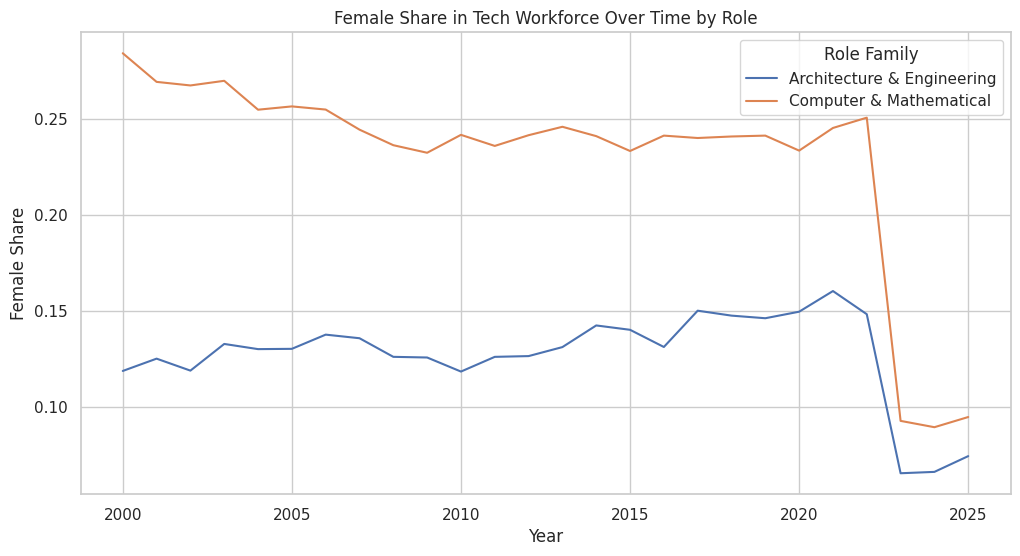

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=role_pivot,
    x="year",
    y="female_share",
    hue="role_family"
)

plt.title("Female Share in Tech Workforce Over Time by Role")
plt.ylabel("Female Share")
plt.xlabel("Year")
plt.legend(title="Role Family")
plt.show()

Rows available for heatmap: 52
Role families: ['Architecture & Engineering' 'Computer & Mathematical']
Years: 2000 to 2025


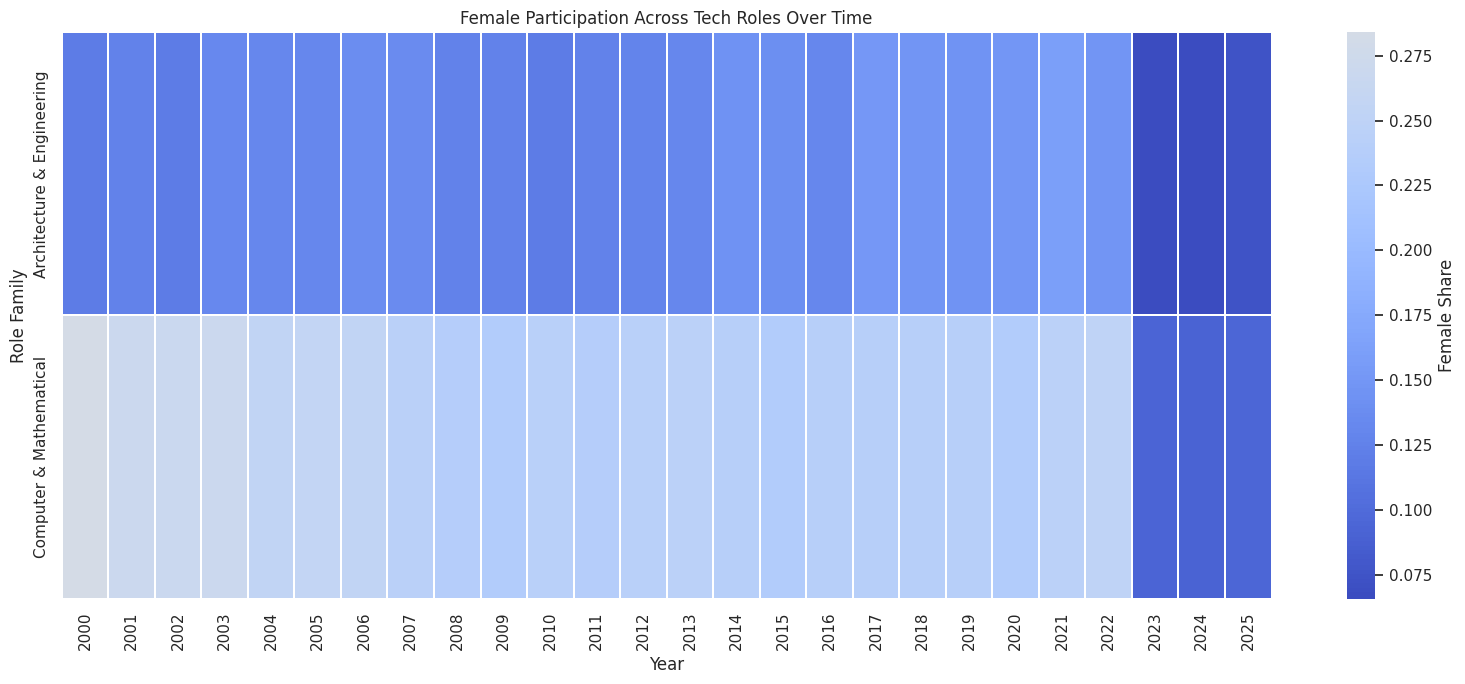

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

heat_df = role_pivot.copy()

# Optional: only keep employed rows if that column exists
if "measure" in heat_df.columns:
    heat_df = heat_df[heat_df["measure"] == "Employed"]

# Ensure female_share exists
if "female_share" not in heat_df.columns:
    heat_df["female_share"] = heat_df["Women"] / heat_df["Total"]

# Clean bad values
heat_df["female_share"] = pd.to_numeric(heat_df["female_share"], errors="coerce")
heat_df = heat_df.replace([np.inf, -np.inf], np.nan)

# Drop rows that cannot be plotted
heat_df = heat_df.dropna(subset=["year", "role_family", "female_share"])

print("Rows available for heatmap:", len(heat_df))
print("Role families:", heat_df["role_family"].unique())
print("Years:", heat_df["year"].min(), "to", heat_df["year"].max())

pivot_heatmap = heat_df.pivot_table(
    index="role_family",
    columns="year",
    values="female_share",
    aggfunc="mean"
)

# Remove fully empty rows/columns
pivot_heatmap = pivot_heatmap.dropna(axis=0, how="all")
pivot_heatmap = pivot_heatmap.dropna(axis=1, how="all")

if pivot_heatmap.empty:
    print("Heatmap is empty. Check whether role_pivot has Employed rows and non-null female_share values.")
else:
    plt.figure(figsize=(16, 7))

    sns.heatmap(
        pivot_heatmap,
        cmap="coolwarm",
        center=0.3,
        annot=False,
        linewidths=0.3,
        cbar_kws={"label": "Female Share"}
    )

    plt.title("Female Participation Across Tech Roles Over Time")
    plt.xlabel("Year")
    plt.ylabel("Role Family")
    plt.tight_layout()
    plt.show()

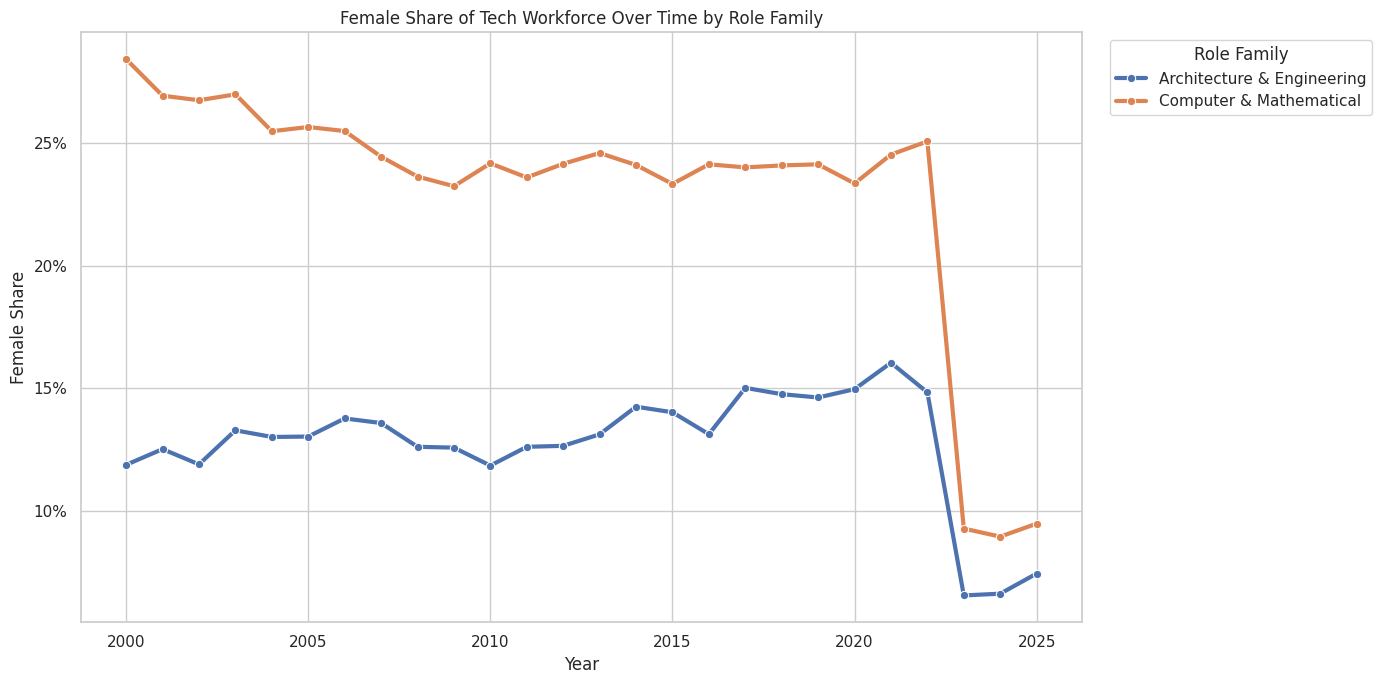

In [65]:
plot_df = role_pivot.copy()
plot_df = plot_df[plot_df["measure"] == "Employed"]
plot_df = plot_df.dropna(subset=["female_share"])

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=plot_df,
    x="year",
    y="female_share",
    hue="role_family",
    linewidth=3,
    marker="o"
)

plt.title("Female Share of Tech Workforce Over Time by Role Family")
plt.xlabel("Year")
plt.ylabel("Female Share")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.legend(title="Role Family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(FIG_DIR / "female_share_by_role_family_line.png", dpi=300, bbox_inches="tight")
plt.show()

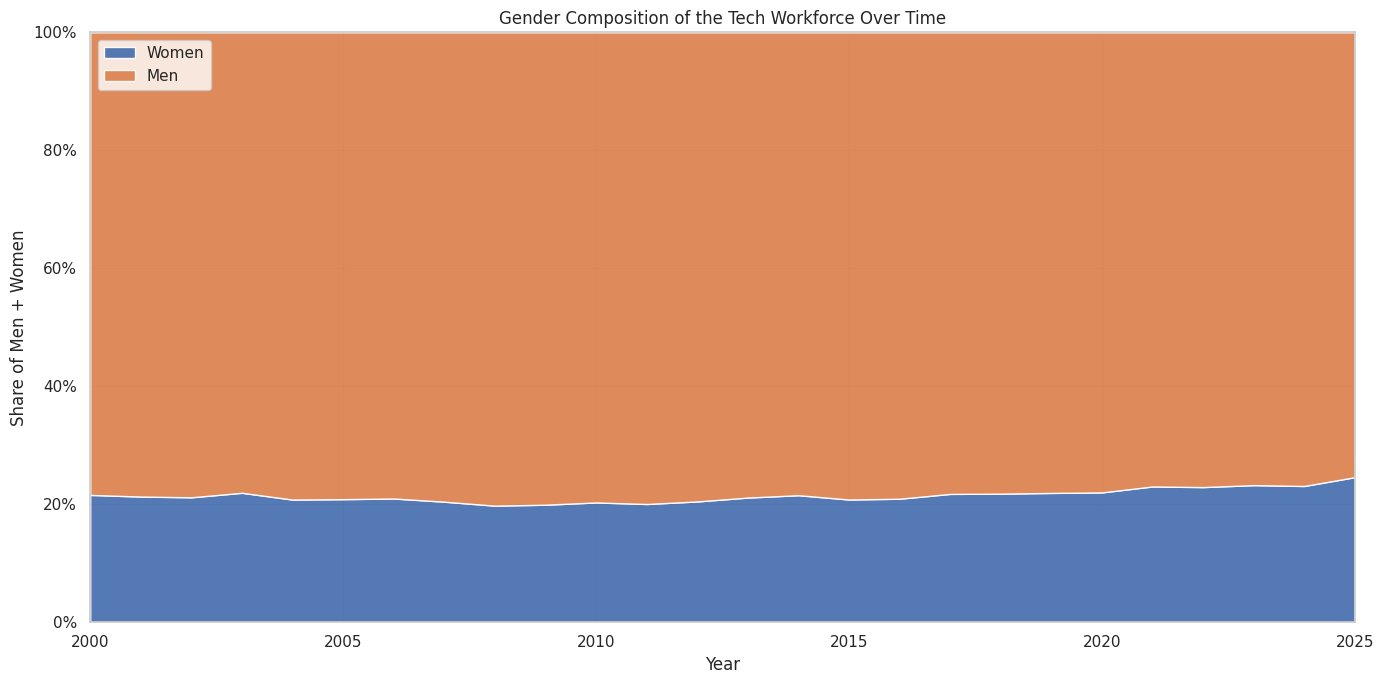

In [66]:
area_df = role_pivot.copy()
area_df = area_df[area_df["measure"] == "Employed"]

# Aggregate across all tech roles by year
area_yearly = (
    area_df
    .groupby("year", as_index=False)[["Men", "Women"]]
    .sum()
    .sort_values("year")
)

# Convert to proportions
area_yearly["total_men_women"] = area_yearly["Men"] + area_yearly["Women"]
area_yearly["men_share"] = area_yearly["Men"] / area_yearly["total_men_women"]
area_yearly["women_share"] = area_yearly["Women"] / area_yearly["total_men_women"]

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(
    area_yearly["year"],
    area_yearly["women_share"],
    area_yearly["men_share"],
    labels=["Women", "Men"],
    alpha=0.95
)

ax.set_title("Gender Composition of the Tech Workforce Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Men + Women")
ax.set_ylim(0, 1)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Remove white padding inside chart
ax.margins(x=0, y=0)
ax.set_facecolor("none")
fig.patch.set_facecolor("white")

ax.legend(loc="upper left")
plt.tight_layout()

plt.savefig(FIG_DIR / "gender_composition_stacked_area.png", dpi=300, bbox_inches="tight")
plt.show()

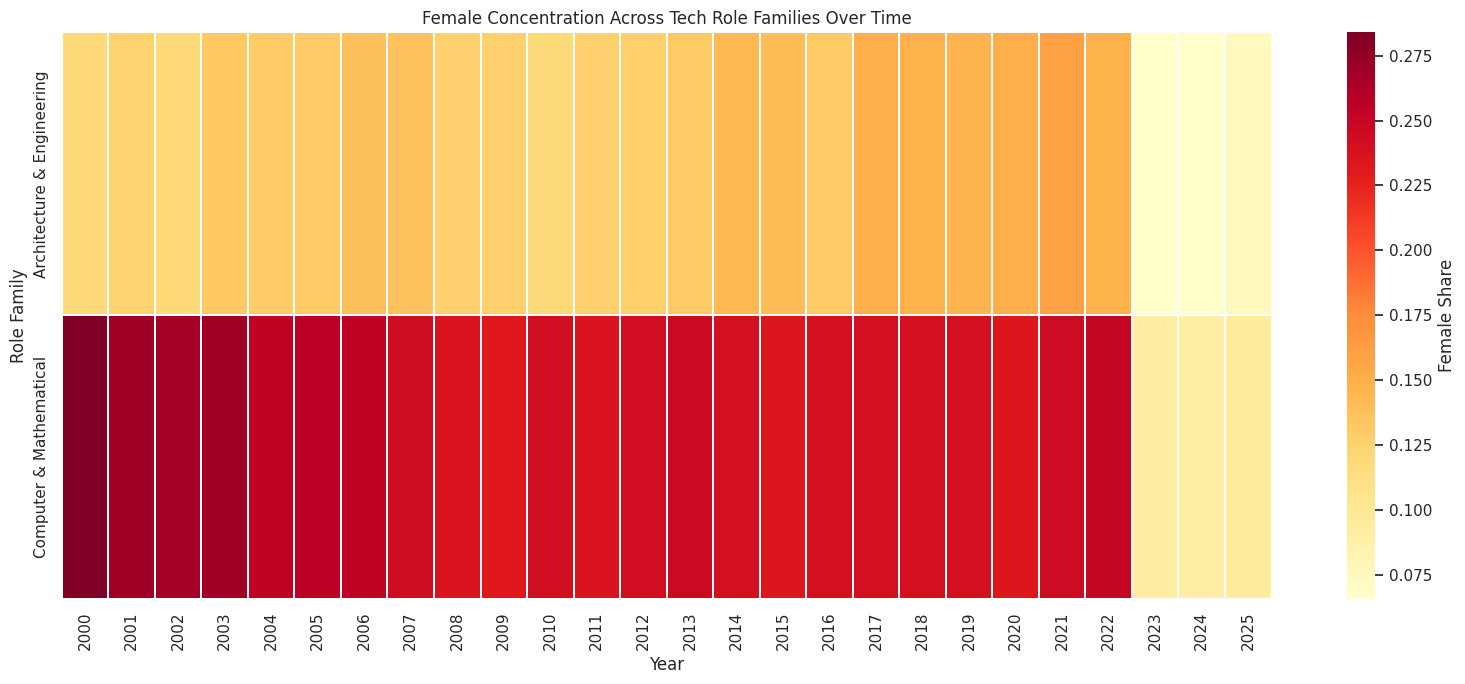

In [67]:
heat_df = role_pivot.copy()
heat_df = heat_df[heat_df["measure"] == "Employed"]
heat_df = heat_df.dropna(subset=["female_share"])

heatmap_data = heat_df.pivot_table(
    index="role_family",
    columns="year",
    values="female_share",
    aggfunc="mean"
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Female Share"}
)

plt.title("Female Concentration Across Tech Role Families Over Time")
plt.xlabel("Year")
plt.ylabel("Role Family")

plt.tight_layout()
plt.savefig(FIG_DIR / "female_concentration_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

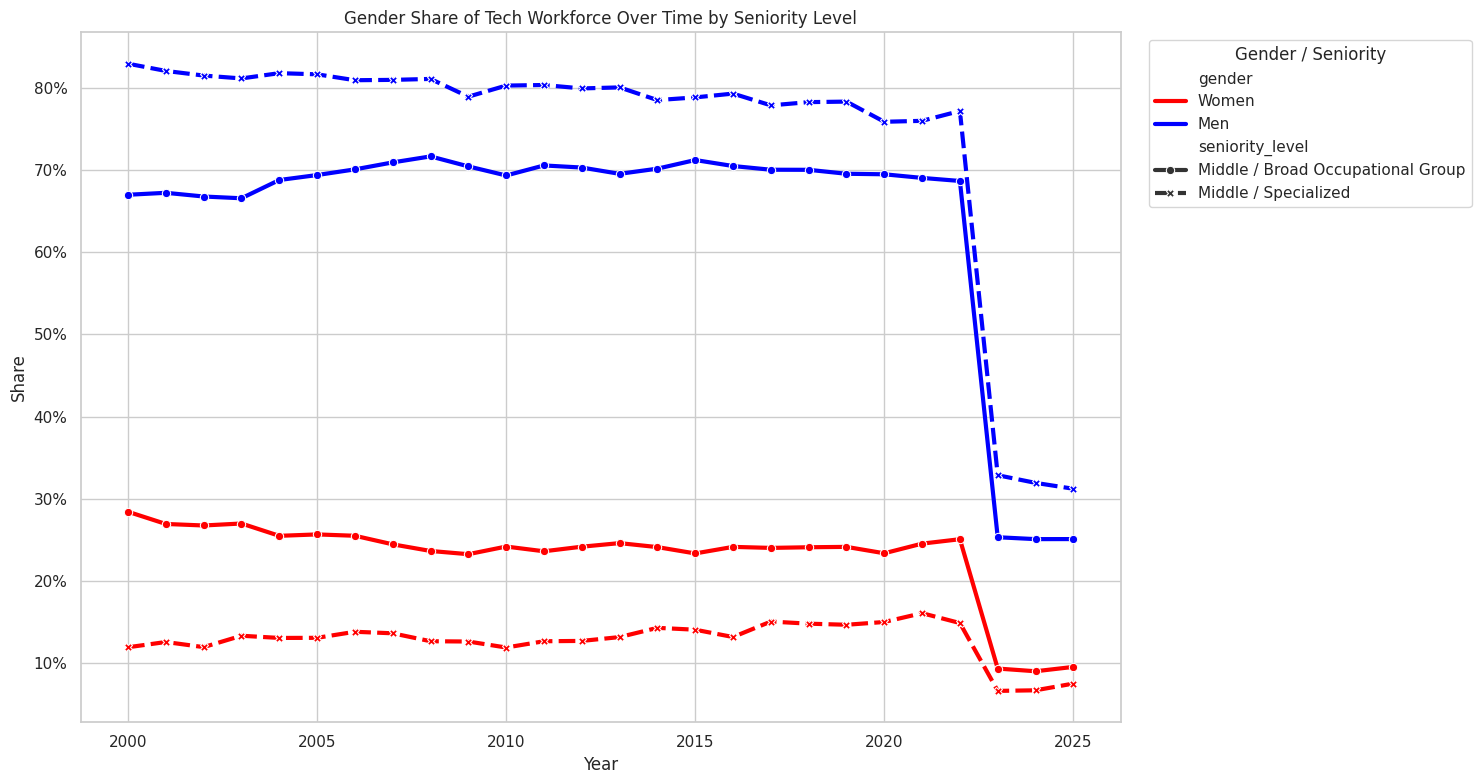

In [71]:
seniority_df = role_pivot.copy()
seniority_df = seniority_df[seniority_df["measure"] == "Employed"]

seniority_yearly = (
    seniority_df
    .groupby(["year", "seniority_level"], as_index=False)[["Women", "Men", "Total"]]
    .sum()
)

seniority_yearly["female_share"] = seniority_yearly["Women"] / seniority_yearly["Total"]
seniority_yearly["male_share"] = seniority_yearly["Men"] / seniority_yearly["Total"]

seniority_long = seniority_yearly.melt(
    id_vars=["year", "seniority_level"],
    value_vars=["female_share", "male_share"],
    var_name="gender",
    value_name="share"
)

seniority_long["gender"] = seniority_long["gender"].map({
    "female_share": "Women",
    "male_share": "Men"
})

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=seniority_long,
    x="year",
    y="share",
    hue="gender",  # Use hue for gender (colors)
    style="seniority_level",  # Use style for seniority level (line types/markers)
    palette={"Women": "red", "Men": "blue"}, # Custom colors for genders
    markers=True, # Ensure distinct markers are used for each style
    linewidth=3
)

plt.title("Gender Share of Tech Workforce Over Time by Seniority Level")
plt.xlabel("Year")
plt.ylabel("Share")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.legend(title="Gender / Seniority", bbox_to_anchor=(1.02, 1), loc="upper left") # Update legend title
plt.tight_layout()

plt.savefig(FIG_DIR / "gender_share_by_seniority_line.png", dpi=300, bbox_inches="tight")
plt.show()

### Gender Disparity in Tech Workforce Over Time

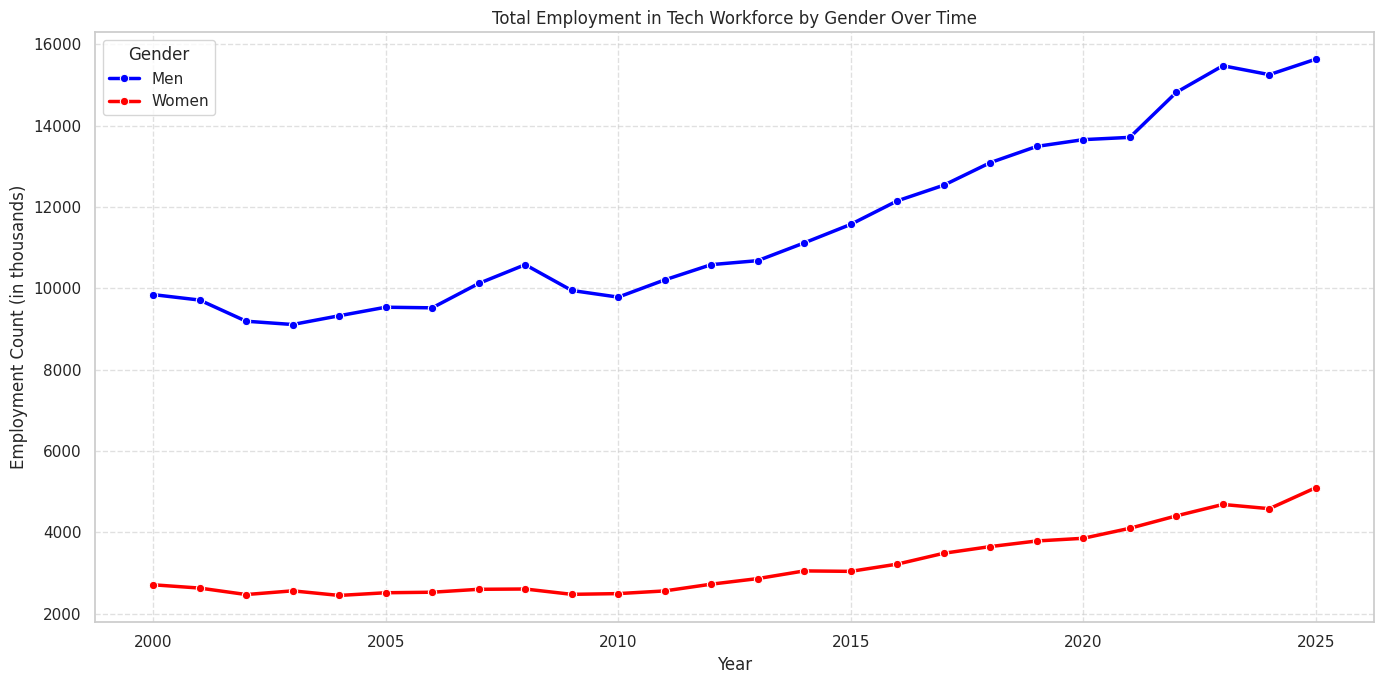

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a melted version of area_yearly for plotting total counts
gender_counts_long = area_yearly.melt(
    id_vars=['year'],
    value_vars=['Men', 'Women'],
    var_name='Gender',
    value_name='Employment Count'
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=gender_counts_long,
    x='year',
    y='Employment Count',
    hue='Gender',
    palette={'Men': 'blue', 'Women': 'red'},
    marker='o',
    linewidth=2.5
)

plt.title('Total Employment in Tech Workforce by Gender Over Time')
plt.xlabel('Year')
plt.ylabel('Employment Count (in thousands)')
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "total_employment_by_gender_line.png", dpi=300, bbox_inches="tight")
plt.show()

The plot above shows the absolute number of employed men and women in the tech workforce over the years. We can also visualize their proportional shares on a single graph for a clearer picture of the disparity.

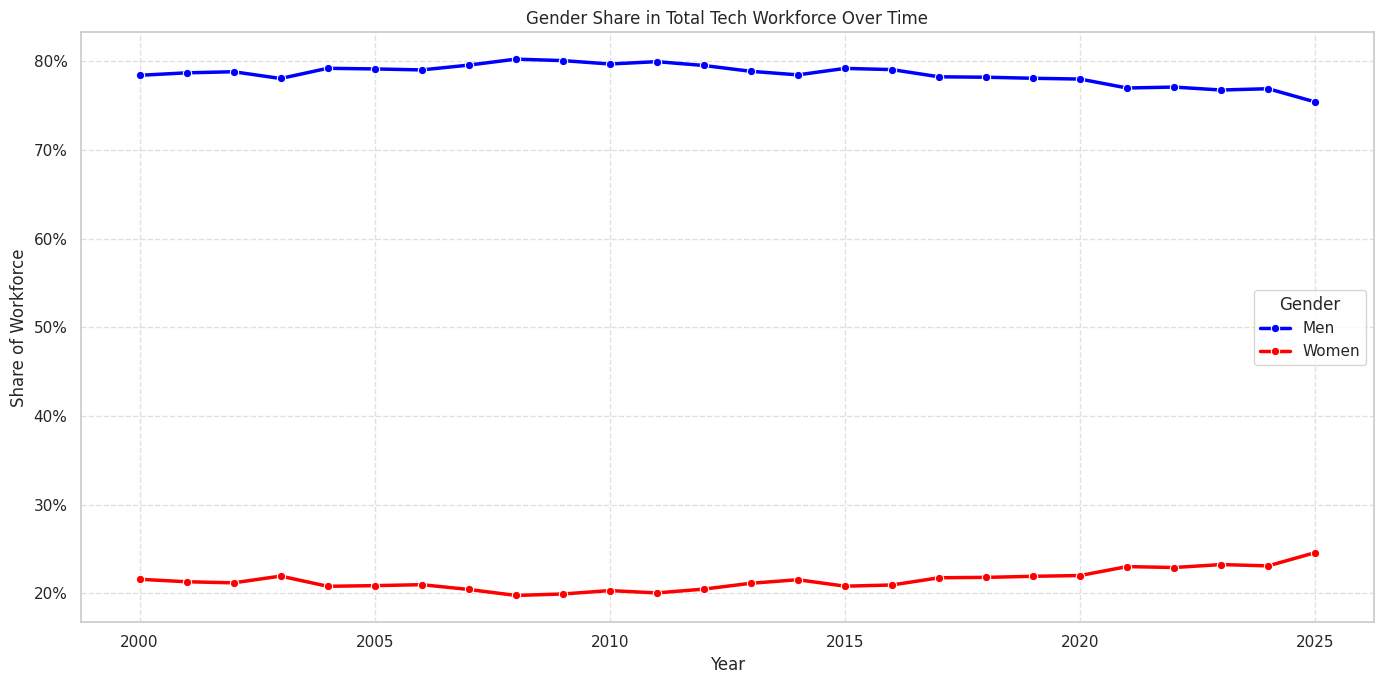

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a melted version of area_yearly for plotting shares
gender_shares_long = area_yearly.melt(
    id_vars=['year'],
    value_vars=['men_share', 'women_share'],
    var_name='Gender Share',
    value_name='Share'
)

gender_shares_long['Gender Share'] = gender_shares_long['Gender Share'].map({
    'men_share': 'Men',
    'women_share': 'Women'
})

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=gender_shares_long,
    x='year',
    y='Share',
    hue='Gender Share',
    palette={'Men': 'blue', 'Women': 'red'},
    marker='o',
    linewidth=2.5
)

plt.title('Gender Share in Total Tech Workforce Over Time')
plt.xlabel('Year')
plt.ylabel('Share of Workforce')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "gender_share_total_tech_line.png", dpi=300, bbox_inches="tight")
plt.show()

### Further Statistical Analysis

In [76]:
from scipy import stats
import statsmodels.api as sm

# Prepare data for statistical analysis
analysis_df = role_pivot[role_pivot['measure'] == 'Employed'].dropna(subset=['female_share'])

print("Descriptive Statistics for Female Share by Role Family:")
display(analysis_df.groupby('role_family')['female_share'].describe())


Descriptive Statistics for Female Share by Role Family:


,count,mean,std,min,25%,50%,75%,max
role_family,,,,,,,,
Architecture & Engineering,26.0,0.127299,0.024078,0.065778,0.125472,0.130872,0.142007,0.160445
Computer & Mathematical,26.0,0.229901,0.052180,0.089701,0.235943,0.241311,0.253635,0.283999


In [ ]:
# T-test to compare female share between Architecture & Engineering and Computer & Mathematical roles
arch_eng_share = analysis_df[analysis_df['role_family'] == 'Architecture & Engineering']['female_share']
comp_math_share = analysis_df[analysis_df['role_family'] == 'Computer & Mathematical']['female_share']

if not arch_eng_share.empty and not comp_math_share.empty:
    t_stat, p_value = stats.ttest_ind(arch_eng_share, comp_math_share, equal_var=False) # Welch's t-test
    print(f"\nIndependent t-test comparing female share in 'Architecture & Engineering' vs 'Computer & Mathematical':")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.3f}")
    if p_value < 0.05:
        print("There is a statistically significant difference in female share between these two role families.")
    else:
        print("There is no statistically significant difference in female share between these two role families.")
else:
    print("Not enough data to perform t-test for one or both role families.")


In [77]:
# Linear regression to analyze female share trend over time for each role family
print("\nLinear Regression Analysis of Female Share Over Time by Role Family:")
for role in analysis_df['role_family'].unique():
    role_df = analysis_df[analysis_df['role_family'] == role].copy()
    if len(role_df) > 1:
        X = sm.add_constant(role_df['year'])
        y = role_df['female_share']
        model = sm.OLS(y, X).fit()
        print(f"\nRole Family: {role}")
        print(model.summary())
    else:
        print(f"\nNot enough data for linear regression for role family: {role}")



Linear Regression Analysis of Female Share Over Time by Role Family:


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

### Workforce Growth Analysis

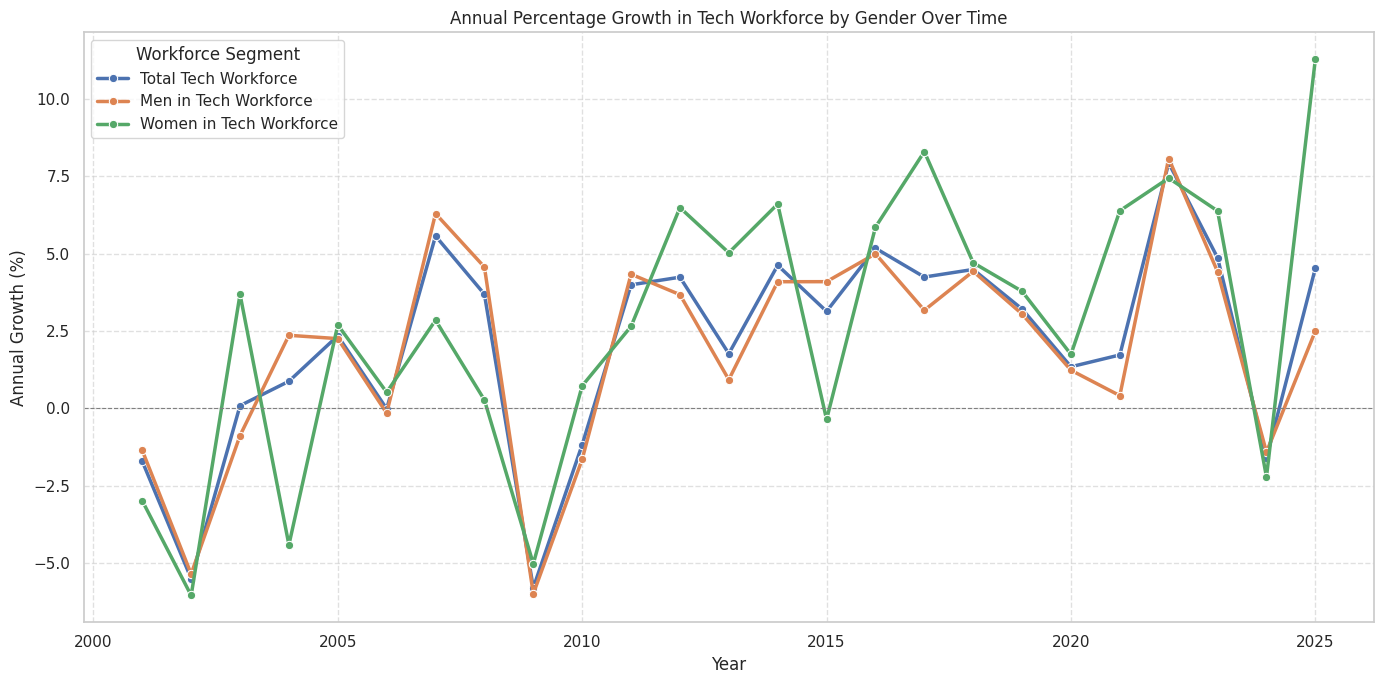

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate year-over-year percentage growth
growth_df = area_yearly.copy()
growth_df['total_workforce_growth_pct'] = growth_df['total_men_women'].pct_change() * 100
growth_df['men_growth_pct'] = growth_df['Men'].pct_change() * 100
growth_df['women_growth_pct'] = growth_df['Women'].pct_change() * 100

# Melt the DataFrame for easier plotting with seaborn
growth_long = growth_df.melt(
    id_vars=['year'],
    value_vars=['total_workforce_growth_pct', 'men_growth_pct', 'women_growth_pct'],
    var_name='Growth Type',
    value_name='Annual Growth (Percentage)'
)

# Map Growth Type to more readable labels
growth_long['Growth Type'] = growth_long['Growth Type'].map({
    'total_workforce_growth_pct': 'Total Tech Workforce',
    'men_growth_pct': 'Men in Tech Workforce',
    'women_growth_pct': 'Women in Tech Workforce'
})

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=growth_long,
    x='year',
    y='Annual Growth (Percentage)',
    hue='Growth Type',
    marker='o',
    linewidth=2.5
)

plt.title('Annual Percentage Growth in Tech Workforce by Gender Over Time')
plt.xlabel('Year')
plt.ylabel('Annual Growth (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a line at 0% growth
plt.legend(title='Workforce Segment')
plt.tight_layout()
plt.savefig(FIG_DIR / "annual_growth_by_gender_line.png", dpi=300, bbox_inches="tight")
plt.show()


### Numerical Summary of Growth and Shares

In [79]:
# Calculate mean annual growth rates
mean_total_growth = growth_long[growth_long['Growth Type'] == 'Total Tech Workforce']['Annual Growth (Percentage)'].mean()
mean_men_growth = growth_long[growth_long['Growth Type'] == 'Men in Tech Workforce']['Annual Growth (Percentage)'].mean()
mean_women_growth = growth_long[growth_long['Growth Type'] == 'Women in Tech Workforce']['Annual Growth (Percentage)'].mean()

print(f"Average Annual Growth - Total Tech Workforce: {mean_total_growth:.2f}%")
print(f"Average Annual Growth - Men in Tech Workforce: {mean_men_growth:.2f}%")
print(f"Average Annual Growth - Women in Tech Workforce: {mean_women_growth:.2f}%")

# Calculate overall average female and male shares
# Using gender_shares_long from previous cells
mean_female_share = gender_shares_long[gender_shares_long['Gender Share'] == 'Women']['Share'].mean()
mean_male_share = gender_shares_long[gender_shares_long['Gender Share'] == 'Men']['Share'].mean()

print(f"\nOverall Average Female Share in Tech Workforce: {mean_female_share:.2%}")
print(f"Overall Average Male Share in Tech Workforce: {mean_male_share:.2%}")


Average Annual Growth - Total Tech Workforce: 2.08%
Average Annual Growth - Men in Tech Workforce: 1.92%
Average Annual Growth - Women in Tech Workforce: 2.65%

Overall Average Female Share in Tech Workforce: 21.48%
Overall Average Male Share in Tech Workforce: 78.52%


### Year-by-Year Female and Male Workforce Shares

In [83]:
shares_table = gender_shares_long.pivot(index='year', columns='Gender Share', values='Share')
display(shares_table.style
    .format('{:.2%}')
    .background_gradient(cmap='RdYlGn', subset=['Women'])
    .background_gradient(cmap='YlGn', subset=['Men'])
    .set_caption('Year-by-Year Female and Male Workforce Shares in Tech')
)

Gender Share,Men,Women
year,,
2000,78.41%,21.59%
2001,78.69%,21.31%
2002,78.82%,21.18%
2003,78.05%,21.95%
2004,79.20%,20.80%
2005,79.13%,20.87%
2006,79.02%,20.98%
2007,79.56%,20.44%
2008,80.24%,19.76%


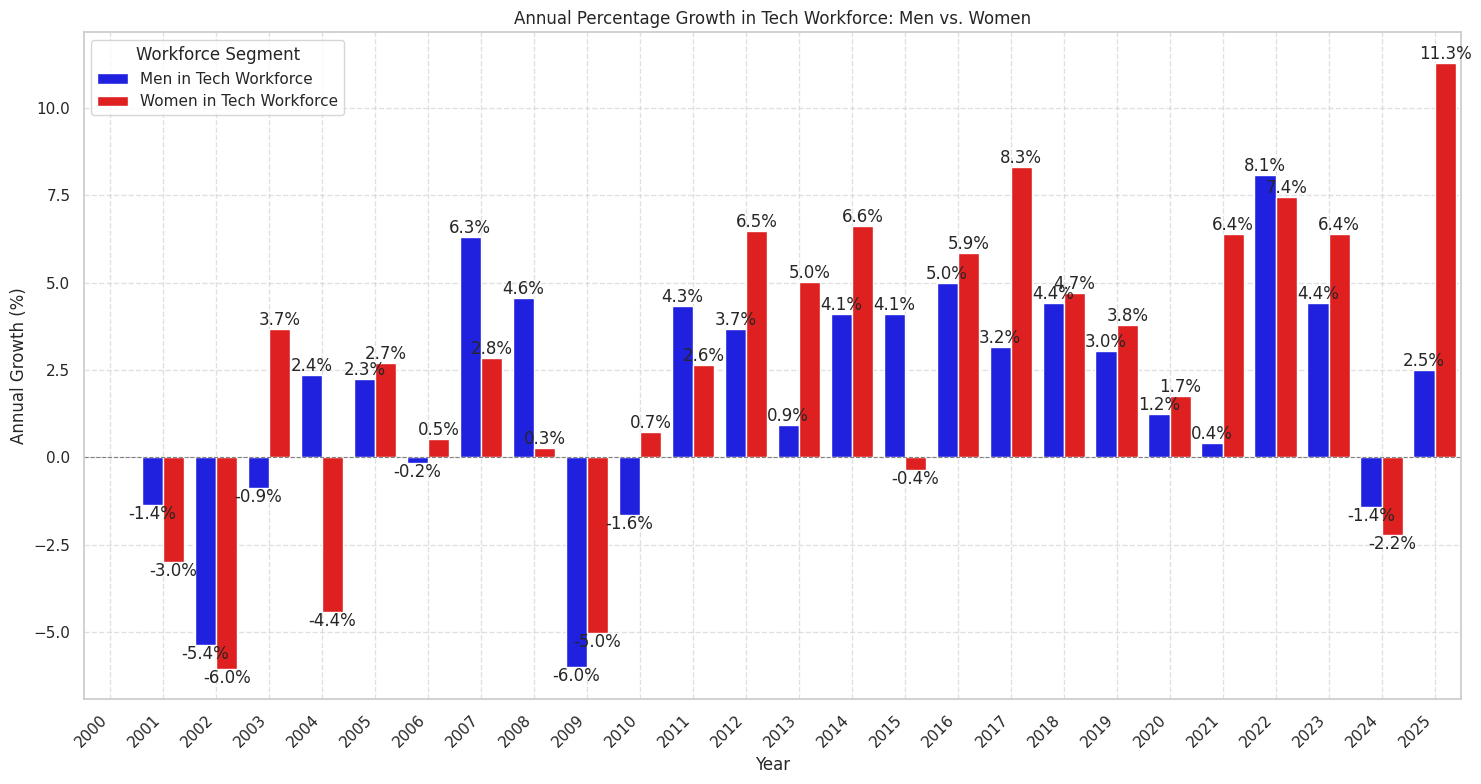

In [85]:
# Bar chart comparing year-to-year growth between men and women
plt.figure(figsize=(15, 8))

growth_men_women = growth_long[growth_long['Growth Type'].isin(['Men in Tech Workforce', 'Women in Tech Workforce'])]

ax = sns.barplot(
    data=growth_men_women,
    x='year',
    y='Annual Growth (Percentage)',
    hue='Growth Type',
    palette={'Men in Tech Workforce': 'blue', 'Women in Tech Workforce': 'red'}
)

plt.title('Annual Percentage Growth in Tech Workforce: Men vs. Women')
plt.xlabel('Year')
plt.ylabel('Annual Growth (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(title='Workforce Segment')
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig(FIG_DIR / "annual_growth_men_women_bar.png", dpi=300, bbox_inches="tight")
plt.show()

### Investigating Missing Seniority Levels

Let's first examine the distribution of seniority levels and role families that were successfully categorized as 'tech-related' from the original `df`.

In [73]:
print("Seniority Level distribution in 'tech' DataFrame:")
display(tech['seniority_level'].value_counts(dropna=False))

print("\nRole Family distribution in 'tech' DataFrame:")
display(tech['role_family'].value_counts(dropna=False))

print("\nUnique Occupation Titles for 'Senior / Leadership' from original `df` that are tech-related:")
senior_titles_df = df[df['occupation_title'].apply(lambda x: categorize_seniority(x) == 'Senior / Leadership')]
senior_titles_tech = senior_titles_df[senior_titles_df['is_tech_related']]
display(senior_titles_tech['occupation_title'].unique())

print("\nUnique Occupation Titles for 'Junior / Support' from original `df` that are tech-related:")
junior_titles_df = df[df['occupation_title'].apply(lambda x: categorize_seniority(x) == 'Junior / Support')]
junior_titles_tech = junior_titles_df[junior_titles_df['is_tech_related']]
display(junior_titles_tech['occupation_title'].unique())

Seniority Level distribution in 'tech' DataFrame:


,count
seniority_level,
Middle / Broad Occupational Group,443
Middle / Specialized,443



Role Family distribution in 'tech' DataFrame:


,count
role_family,
Computer & Mathematical,443
Architecture & Engineering,443



Unique Occupation Titles for 'Senior / Leadership' from original `df` that are tech-related:


array([], dtype=object)


Unique Occupation Titles for 'Junior / Support' from original `df` that are tech-related:


array([], dtype=object)

### Statistical Comparison of Gender Shares in Senior and Middle Management

In [72]:
# Filter for 'Senior / Leadership' and 'Middle / Specialized' seniority levels
filtered_seniority_long = seniority_long[
    seniority_long["seniority_level"].isin(["Senior / Leadership", "Middle / Specialized"])
]

# Calculate the average share for each gender and seniority level
average_shares = filtered_seniority_long.groupby(["seniority_level", "gender"])[["share"]].mean().unstack()

display(average_shares)

# Calculate the difference for more direct comparison
difference_in_shares = average_shares[('share', 'Men')] - average_shares[('share', 'Women')]
print("\nAverage difference (Men's share - Women's share):")
display(difference_in_shares)

share          
gender                     Men     Women
seniority_level                         
Middle / Specialized  0.742526  0.127299


Average difference (Men's share - Women's share):


,0
seniority_level,
Middle / Specialized,0.615227


In [69]:
role_pivot["role_family"].value_counts()

,count
role_family,
Architecture & Engineering,26
Computer & Mathematical,26


# New approach - sectors